<a href="https://colab.research.google.com/github/Hitesh-95/project-work/blob/main/Copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install tensorflow numpy matplotlib opencv-python

In [5]:
from tensorflow.keras.models import load_model

model_path = "/model.h5"  # Change this if using Google Drive
model = load_model(model_path)
print("Model loaded successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model loaded successfully!


Saving AppleCedarRust2.JPG to AppleCedarRust2 (1).JPG


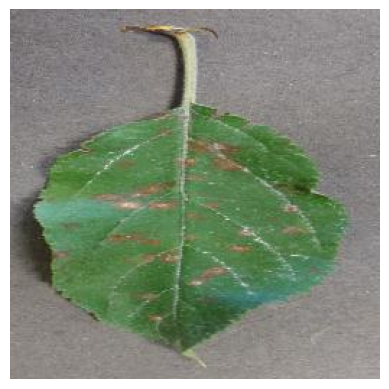

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Predicted Disease: Early Blight


In [9]:
# Install required libraries
!pip install tensorflow numpy matplotlib opencv-python

import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# Load the trained model
model_path = "/model.h5"  # Change if stored in Google Drive
model = load_model(model_path)

# Define class names (modify this according to your dataset)
class_names = ["Healthy", "Bacterial Spot", "Early Blight", "Late Blight",
               "Leaf Mold", "Septoria Leaf Spot", "Spider Mites",
               "Target Spot", "Yellow Leaf Curl Virus", "Mosaic Virus"]

# Function to preprocess the uploaded image
def preprocess_image(img):
    img = img.resize((224, 224))  # Resize to match model input
    img = np.array(img) / 255.0   # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Upload an image
def upload_and_predict():
    uploaded = files.upload()  # Upload image
    for filename in uploaded.keys():
        img = Image.open(filename)  # Open image
        img_array = preprocess_image(img)  # Preprocess

        # Show the image
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # Predict using model
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)  # Get class index
        disease_name = class_names[predicted_class]  # Get disease name

        print(f"Predicted Disease: {disease_name}")

# Run the function
upload_and_predict()

Saving PotatoEarlyBlight3.JPG to PotatoEarlyBlight3.JPG


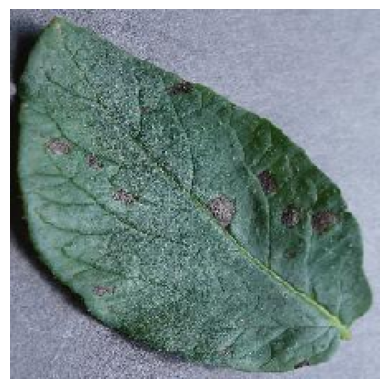

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
✅ Predicted Disease: Soybean - Healthy


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# Load the trained model
model = load_model("/model.h5")

# Define a full list of plant diseases (Update based on your dataset)
class_names = [
    "Apple - Apple Scab", "Apple - Black Rot", "Apple - Cedar Apple Rust", "Apple - Healthy",
    "Blueberry - Healthy",
    "Cherry - Powdery Mildew", "Cherry - Healthy",
    "Corn - Cercospora Leaf Spot (Gray Leaf Spot)", "Corn - Common Rust", "Corn - Northern Leaf Blight", "Corn - Healthy",
    "Grape - Black Rot", "Grape - Esca (Black Measles)", "Grape - Leaf Blight (Isariopsis Leaf Spot)", "Grape - Healthy",
    "Orange - Haunglongbing (Citrus Greening)",
    "Peach - Bacterial Spot", "Peach - Healthy",
    "Pepper - Bacterial Spot", "Pepper - Healthy",
    "Potato - Early Blight", "Potato - Late Blight", "Potato - Healthy",
    "Raspberry - Healthy",
    "Soybean - Healthy",
    "Squash - Powdery Mildew",
    "Strawberry - Leaf Scorch", "Strawberry - Healthy",
    "Tomato - Bacterial Spot", "Tomato - Early Blight", "Tomato - Late Blight",
    "Tomato - Leaf Mold", "Tomato - Septoria Leaf Spot",
    "Tomato - Spider Mites (Two-Spotted Spider Mite)", "Tomato - Target Spot",
    "Tomato - Yellow Leaf Curl Virus", "Tomato - Mosaic Virus", "Tomato - Healthy"
]

# Function to upload an image and predict disease
def upload_and_predict():
    uploaded = files.upload()  # Upload image
    for filename in uploaded.keys():
        img_path = filename

        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))  # Resize to model's expected size
        img_array = image.img_to_array(img) / 255.0  # Normalize
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Show the uploaded image
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # Make prediction
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)  # Get class index

        # Check if predicted class is valid
        if predicted_class >= len(class_names):
            print("❌ Error: Predicted class index is out of range!")
        else:
            disease_name = class_names[predicted_class]
            print(f"✅ Predicted Disease: {disease_name}")

# Run the function
upload_and_predict()